In [1]:
import sys
import os
from pathlib import Path

notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent
print(ROOT)
RAFT_PATH = ROOT / "external" / "RAFT-Stereo"
os.chdir(ROOT)
if str(RAFT_PATH) not in sys.path:
    sys.path.append(str(ROOT))

/srv/homes/onbo10/thesis_main


In [2]:
from utilities.visualizer_triangulation import TriangulationVisualizer
from src.Geometry.triangulation.triangulator import Triangulator
import cv2
from src.Geometry.triangulation.triangulation_utils import *
import matplotlib.pyplot as plt
import os
import random
import numpy as np
from pathlib import Path


In [3]:
def plot_random_disparities(base_results_path, num_samples=10, seed=50):
    
    random.seed(seed)
    np.random.seed(seed)
    
    base_path = Path(base_results_path)
    
    all_files = list(base_path.glob("**/compressed_data/*.npz"))
    
    if not all_files:
        print(f"No .npz files found in {base_results_path}")
        return

    selected_files = random.sample(all_files, min(num_samples, len(all_files)))
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f"Examples of Disparity Maps", fontsize=16)
    axes = axes.flatten()

    for i, file_path in enumerate(selected_files):
        # Load the data
        data = np.load(file_path)
        disp = data['disparity']
        
        # Plotting
        im = axes[i].imshow(disp, cmap='jet')
        axes[i].set_title(f"File: {file_path.stem}", fontsize=8)
        axes[i].axis('off')
    

    plt.tight_layout()
    plt.show()
    return selected_files



### Raft Stereo results

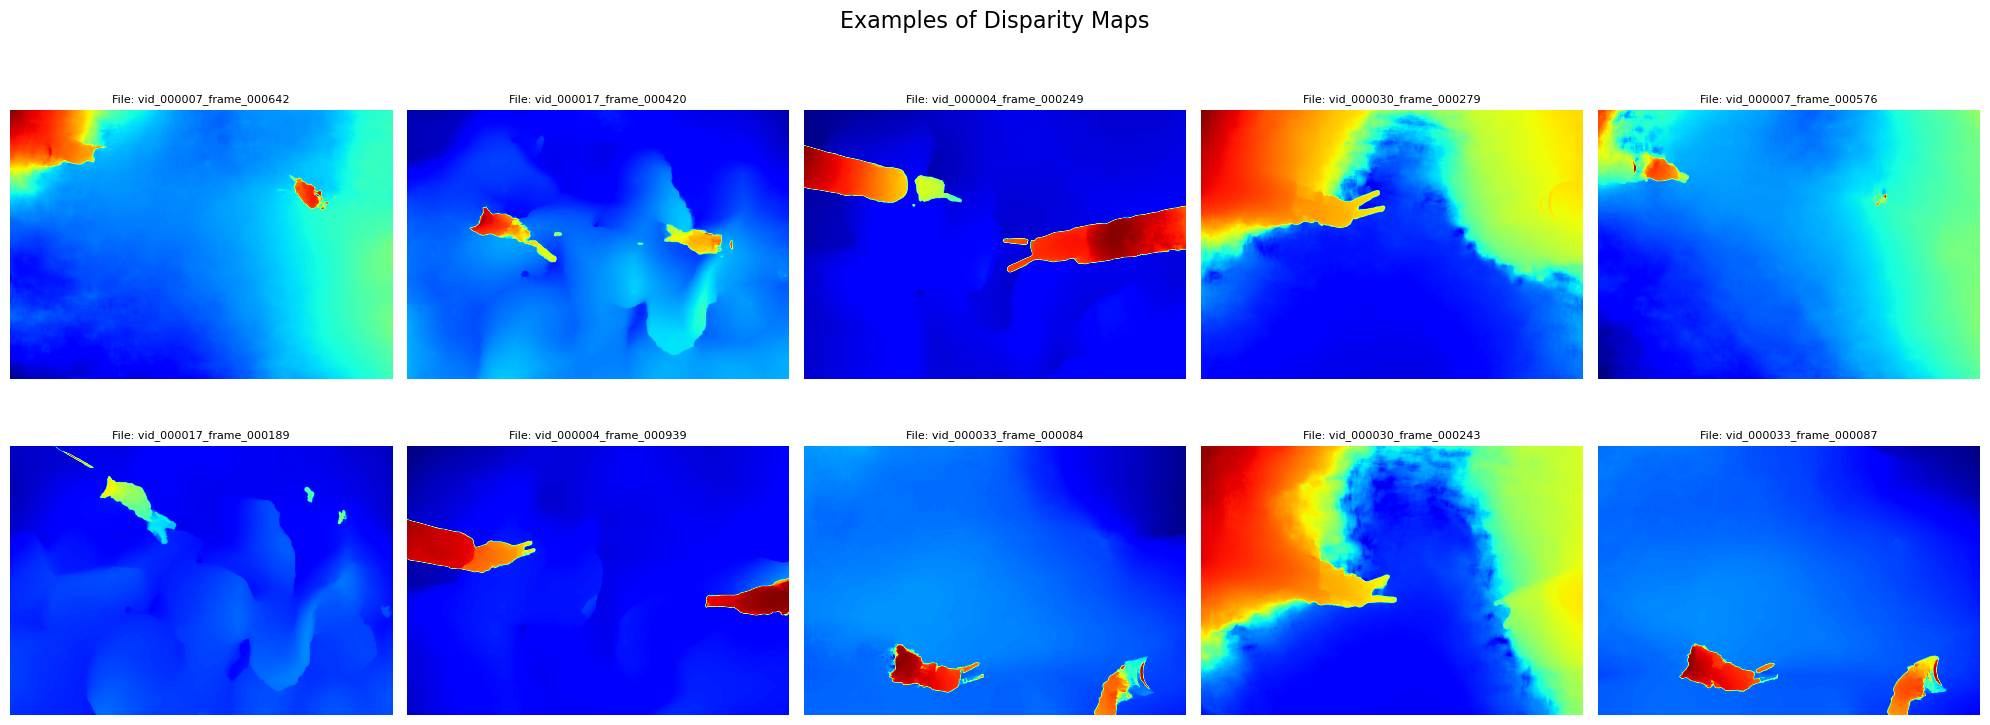

In [61]:

results_dir= "results/Stereo_matching/Surgpose_test_disparity_maps/raftstereo"
selected_files= plot_random_disparities(results_dir)

In [5]:
selected_files

[PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000007/compressed_data/vid_000007_frame_000642.npz'),
 PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000017/compressed_data/vid_000017_frame_000420.npz'),
 PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000004/compressed_data/vid_000004_frame_000249.npz'),
 PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000030/compressed_data/vid_000030_frame_000279.npz'),
 PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000007/compressed_data/vid_000007_frame_000576.npz'),
 PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000017/compressed_data/vid_000017_frame_000189.npz'),
 PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000004/compressed_data/vid_000004_frame_000939.npz'),
 PosixPath('results/Stereo_matching/Surgpose_test_disparity_maps/000033/compressed_data/vid_000033_frame_000084.npz'),
 PosixPath('results/Stereo_matching/Surgpose_tes

In [45]:
idx= 6

In [46]:

npz_file_path = selected_files[idx]

video_id = npz_file_path.parents[1].name 

file_stem = npz_file_path.stem 
frame_number = file_stem.split('_frame_')[-1]

left_mask_path = f"data/Surgpose_for_segmentation/left_test_set/binary_masks/vid_{video_id}_left_frame_{frame_number}.png"
right_mask_path = left_mask_path.replace('left', 'right')

zip_calib_path = f"data/SurgPose/SurgPose_for_HRNet/{video_id}.zip"

left_img_path = f"data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames/{video_id}/vid_{video_id}_left_frame_{frame_number}.jpg"
right_img_path = f"data/SurgPose/SurgPose_for_HRNet/Extracted_right_test/extracted_frames/{video_id}/vid_{video_id}_right_frame_{frame_number}.jpg"
frame_id= file_stem.split('.')[0]
print(f"Processing Video: {video_id}, Frame: {frame_number}")
print(f"Mask: {left_mask_path}")
print(f"Image: {left_img_path}")
print(f"Calib: {zip_calib_path}")
print(f"frame_id: {frame_id}")


Processing Video: 000004, Frame: 000000
Mask: data/Surgpose_for_segmentation/left_test_set/binary_masks/vid_000004_left_frame_000000.png
Image: data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames/000004/vid_000004_left_frame_000000.jpg
Calib: data/SurgPose/SurgPose_for_HRNet/000004.zip
frame_id: vid_000004_frame_000000


In [47]:
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path);

In [48]:

#Load Masks
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)
img_l = cv2.imread(left_img_path)
img_r= cv2.imread(right_img_path)
h, w = img_l.shape[:2]


In [49]:
mode = "conventional"
lmap1, lmap2, rmap1, rmap2, q= triangulator.get_rectification_maps(img_size=(h,w), mode=mode)
rect_l, rect_r = triangulator.rectify_images(img_l, img_r,lmap1, lmap2, rmap1, rmap2, mode)
rect_mask_l = cv2.remap(mask_l, lmap1, lmap2, cv2.INTER_NEAREST)
rect_mask_r = cv2.remap(mask_r, rmap1, rmap2, cv2.INTER_NEAREST)


In [50]:

data = np.load(npz_file_path)
disp_l =  data['disparity']
lrc_mask = data['lrc_mask']

In [51]:
points_3d_cloud, colors, disparity = triangulator.project_disparity_to_3d(disp_l*lrc_mask, q, rect_l, rect_mask_l)

In [52]:
visualizer = TriangulationVisualizer()
visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id)

#### LRC stats

In [60]:
import pandas as pd
lrc_stats='results/Stereo_matching/Surgpose_test_disparity_maps/raftstereo/lrc_stats_20260422_143449.csv'
df= pd.read_csv(lrc_stats)

In [54]:
df.head(10)

,video_id,frame,lrc_mean,lrc_std,lrc_max,lrc_min,consistency_rate
0,4,vid_000004_left_frame_000000,0.9906,4.8800,54.0064,0.0,91.92
1,4,vid_000004_left_frame_000003,1.1787,5.0705,56.4388,0.0,89.11
2,4,vid_000004_left_frame_000006,1.0677,5.4643,63.9004,0.0,92.49
3,4,vid_000004_left_frame_000009,1.0773,5.4838,63.4718,0.0,91.88
4,4,vid_000004_left_frame_000012,1.2045,5.7852,65.0734,0.0,89.74
5,4,vid_000004_left_frame_000015,1.1025,5.6855,67.4016,0.0,93.79
6,4,vid_000004_left_frame_000018,1.2036,6.0078,71.8710,0.0,92.35
7,4,vid_000004_left_frame_000021,1.0795,5.8420,69.1739,0.0,94.74
8,4,vid_000004_left_frame_000024,1.1177,5.7841,69.6130,0.0,94.17
9,4,vid_000004_left_frame_000027,1.2334,6.1028,66.2542,0.0,91.64


In [55]:
df.mean().drop('video_id')

/srv/homes/onbo10/.conda/envs/raftstereo/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning:

Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.



lrc_mean             1.12555
lrc_std              5.61060
lrc_max             64.72045
lrc_min              0.00000
consistency_rate    92.18300
dtype: float64

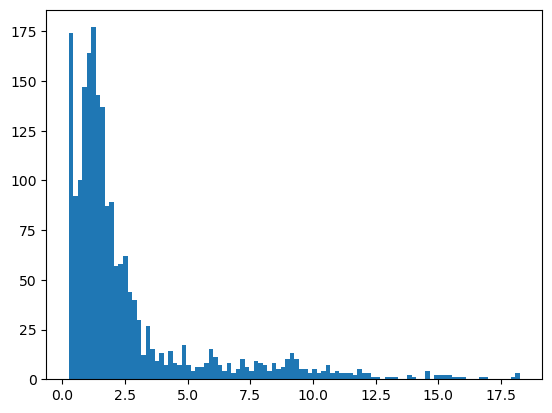

In [28]:
plt.hist(df['lrc_mean'], bins=100)
plt.show()

###  SGBM results


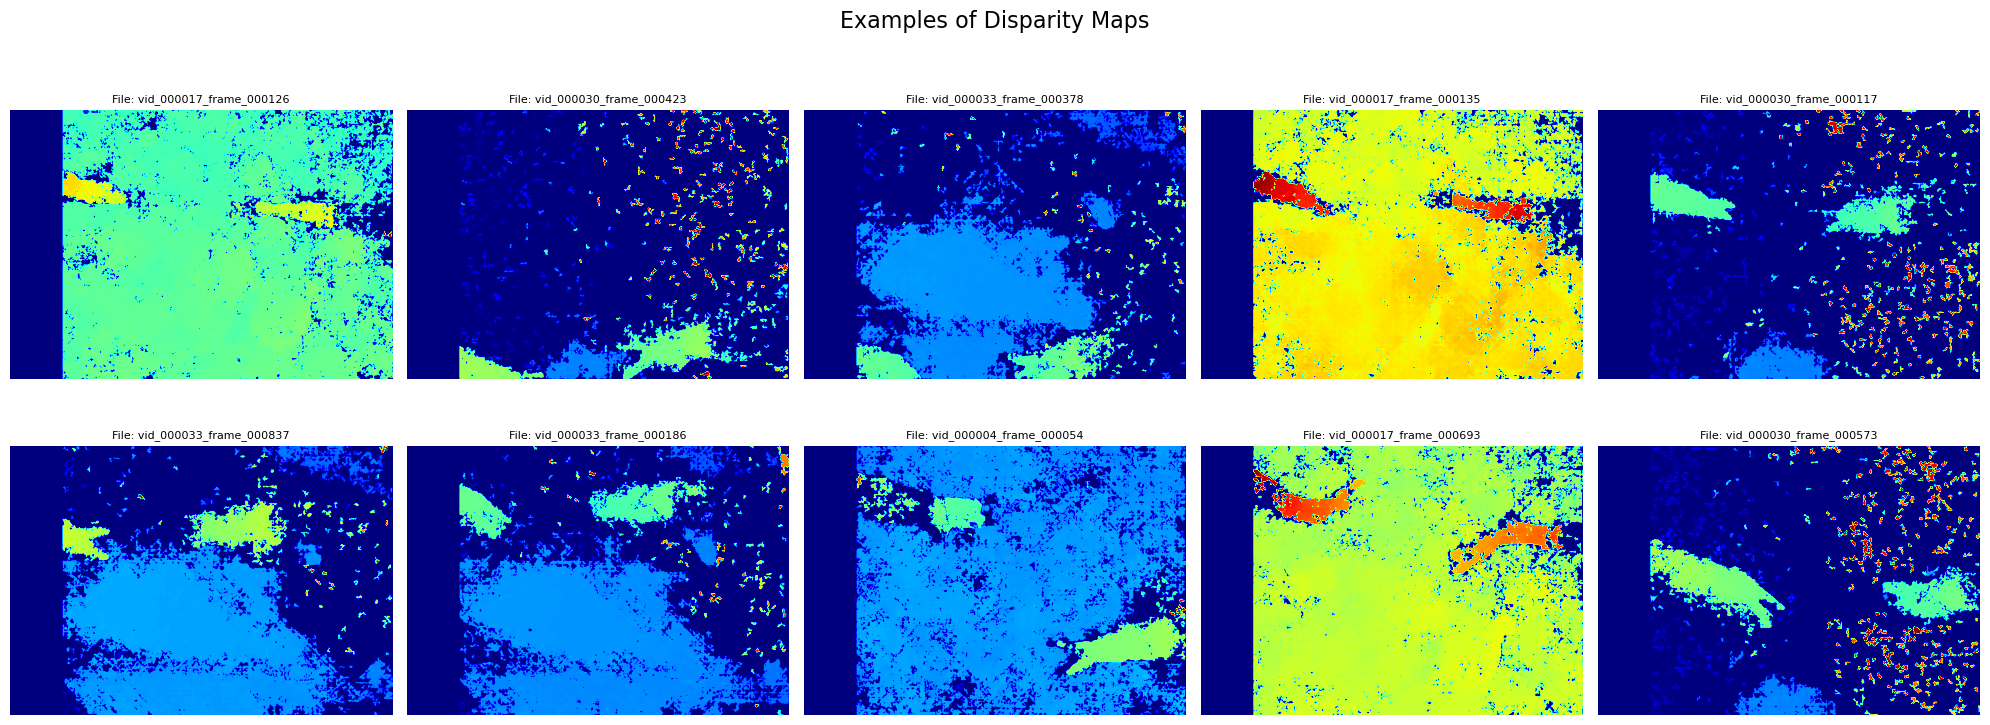

In [103]:

results_dir= "results/Stereo_matching/Surgpose_test_disparity_maps/sgbm"
selected_files= plot_random_disparities(results_dir)

In [104]:
idx= 6


In [105]:

npz_file_path = selected_files[idx]

video_id = npz_file_path.parents[1].name 

file_stem = npz_file_path.stem 
frame_number = file_stem.split('_frame_')[-1]

left_mask_path = f"data/Surgpose_for_segmentation/left_test_set/binary_masks/vid_{video_id}_left_frame_{frame_number}.png"
right_mask_path = left_mask_path.replace('left', 'right')

zip_calib_path = f"data/SurgPose/SurgPose_for_HRNet/{video_id}.zip"

left_img_path = f"data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames/{video_id}/vid_{video_id}_left_frame_{frame_number}.jpg"
right_img_path = f"data/SurgPose/SurgPose_for_HRNet/Extracted_right_test/extracted_frames/{video_id}/vid_{video_id}_right_frame_{frame_number}.jpg"
frame_id= file_stem.split('.')[0]
print(f"Processing Video: {video_id}, Frame: {frame_number}")
print(f"Mask: {left_mask_path}")
print(f"Image: {left_img_path}")
print(f"Calib: {zip_calib_path}")
print(f"frame_id: {frame_id}")


Processing Video: 000033, Frame: 000186
Mask: data/Surgpose_for_segmentation/left_test_set/binary_masks/vid_000033_left_frame_000186.png
Image: data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames/000033/vid_000033_left_frame_000186.jpg
Calib: data/SurgPose/SurgPose_for_HRNet/000033.zip
frame_id: vid_000033_frame_000186


In [106]:
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path);

In [107]:
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)
img_l = cv2.imread(left_img_path)
img_r= cv2.imread(right_img_path)
h, w = img_l.shape[:2]


In [108]:
mode = "conventional"
lmap1, lmap2, rmap1, rmap2, q= triangulator.get_rectification_maps(img_size=(h,w), mode=mode)
rect_l, rect_r = triangulator.rectify_images(img_l, img_r,lmap1, lmap2, rmap1, rmap2, mode)
rect_mask_l = cv2.remap(mask_l, lmap1, lmap2, cv2.INTER_NEAREST)
rect_mask_r = cv2.remap(mask_r, rmap1, rmap2, cv2.INTER_NEAREST)


In [109]:
from src.Stereo_matching.inference.SGBM_matcher_inferencer import SGBMInferencer

In [110]:
inferencer= SGBMInferencer()


In [111]:
disp_l, disp_r= inferencer.get_bidirectional_disparity(rect_l,rect_r)

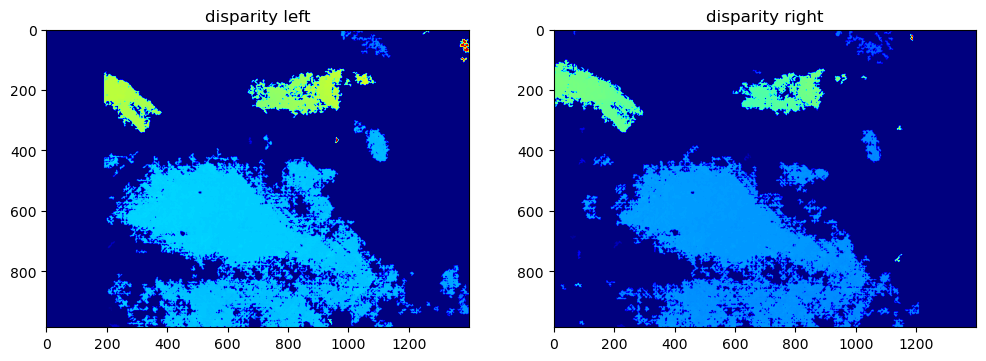

In [112]:
fig, axes= plt.subplots(1,2,figsize=(12, 6))
axes[0].imshow(disp_l, cmap='jet')
axes[0].set_title('disparity left')
axes[1].imshow(disp_r, cmap='jet')
axes[1].set_title('disparity right')
plt.show()

In [113]:

data = np.load(npz_file_path)
disp_l =  data['disparity']
lrc_mask = data['lrc_mask']

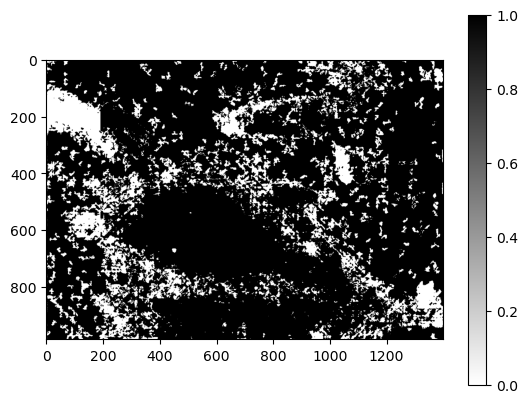

In [114]:
plt.imshow(lrc_mask,cmap='binary')
plt.colorbar()

In [115]:
points_3d_cloud, colors, disparity = triangulator.project_disparity_to_3d(disp_l*lrc_mask, q, rect_l, rect_mask_l)

In [116]:
visualizer = TriangulationVisualizer()
visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id)

In [117]:
import pandas as pd
lrc_stats='results/Stereo_matching/Surgpose_test_disparity_maps/sgbm/lrc_stats_20260423_133557.csv'
df= pd.read_csv(lrc_stats)

In [118]:
df.head(10)

,video_id,frame,lrc_mean,lrc_std,lrc_max,lrc_min,consistency_rate
0,4,vid_000004_left_frame_000000,15.1708,26.5267,190.9375,0.0,71.85
1,4,vid_000004_left_frame_000003,16.0637,27.0515,171.8750,0.0,70.44
2,4,vid_000004_left_frame_000006,15.5815,26.9299,186.3750,0.0,71.56
3,4,vid_000004_left_frame_000009,15.5785,26.9231,191.2500,0.0,71.47
4,4,vid_000004_left_frame_000012,16.1937,27.3084,185.1875,0.0,70.50
5,4,vid_000004_left_frame_000015,15.7112,27.1111,186.1250,0.0,71.48
6,4,vid_000004_left_frame_000018,16.0514,27.3069,192.0000,0.0,70.84
7,4,vid_000004_left_frame_000021,16.1758,27.4495,191.0000,0.0,70.66
8,4,vid_000004_left_frame_000024,16.3592,27.5710,189.0625,0.0,70.26
9,4,vid_000004_left_frame_000027,16.7489,27.7536,192.0000,0.0,69.70


In [119]:
df.mean().drop('video_id')

/srv/homes/onbo10/.conda/envs/raftstereo/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning:

Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.



lrc_mean             13.091511
lrc_std              28.446277
lrc_max             173.693633
lrc_min               0.000000
consistency_rate     77.042273
dtype: float64

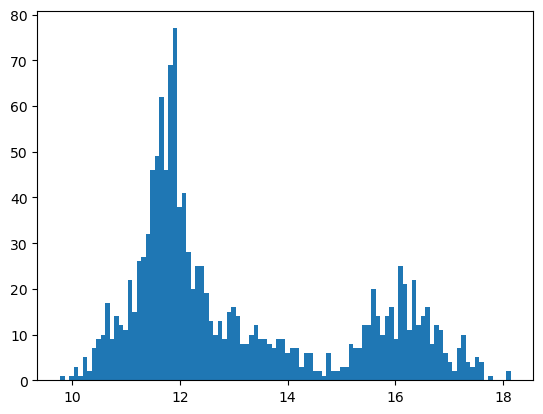

In [120]:
plt.hist(df['lrc_mean'], bins=100)
plt.show()